# Single Ticker learning on SP100 daily prices — return/variance features (`Mains.multislice`)

This notebook uses the **multislice** pipeline and the **`return_variance`** feature set
(`feature_set return_variance` in the parameter file), but does so only for single tickers. The network's **decode/prediction target is the daily return** (`feats[:, 2]`, today/yesterday) and the **secondary encoded channel is a left-sided, direction-agnostic return variance** (`feats[:, 3]`). This is the sibling of `notebook-multislice_demo.ipynb`,which instead predicts the trailing-mean price level with a 1st-derivative side channel.
> **Note:** The dataset is whatever `timeseries_file` the parameter file points at (here
> `datasets/sp100_IPO_sorted.csv`, S&P 100 constituents), but narrowed doen to a particular stock/ticker. The notebook reads it once via `DATA_CSV` so the displayed prices, the per-ticker features, and `Mains.multislice()` all stay aligned.

In [19]:
#Imports and static variables
import os
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

import Utils
import FeatureGeneration as FG
import RBFBinner
import Mains
import Display


for m in (Utils, FG, Mains, Display):
    importlib.reload(m)
WORKDIR = os.path.dirname(os.path.abspath("Mains.py")) if os.path.exists("Mains.py") else os.getcwd()
os.chdir(WORKDIR)
FIGDIR = "figs/SP100/1ticker"
os.makedirs(FIGDIR, exist_ok=True)


def figpath(n, stem):
    """Numbered figure path under FIGDIR (``01_…`` through ``99_…``)."""
    return os.path.join(FIGDIR, f"{int(n):02d}_{stem}.png")


def save_fig(fig, n, stem):
    """Save *fig* to FIGDIR with a zero-padded sequence number."""
    path = figpath(n, stem)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return path

# Figure index (all saved under FIGDIR via save_fig / figpath):
#  01 raw_sp100_closes
#  02 rolling_features_<sym>   03 rbf_encoding_<sym>
#  04 return_distribution_raw_vs_log   (reserved — not yet plotted)
#  05 block_coverage_train_val_test
#  06 per_ticker_test_rmse_by_block   07 best_worst_performer_prices
#  08 aggregate_test_error_vs_block   09 test_rmse_heatmap_tickers_blocks
#  10 cross_sectional_mean_test_rmse
#  11–13 block_sweep_*   (reserved — §8b skipped)
#  14 1ticker_prediction_<sym>
#  15 ticker_sweep_test_rmse_vs_n_tickers   16 ticker_sweep_rmse_phases   17 ticker_sweep_elapsed_time
#  18 return_transition_<sym>   19 return_persistence_<sym>
#  20 return_transition_all   21 return_persistence_all   22 return_persistence_summary
#  23 ea_trajectory   24 ea_near_optimal_marginals   25 ea_near_optimal_pairs
#  26 ea_cluster_pca   27 ea_cluster_profiles   28 ea_generalisation
#  (§7 param sweeps: unnumbered sweep_*.png under FIGDIR)



PARAMFILE = "Parameters_1ticker.par"
params = Utils.load_params(PARAMFILE)
if "tickers" in params:
    TICKERS = params["tickers"].split(",")
else:
    TICKERS = FG.csv_ticker_columns(params["timeseries_file"])
TRNPAT = int(params["trnpat"])
VANPAT = int(params["vanpat"])
TENPAT = int(params["tenpat"])
OFFS = int(params["offs"])
WARMUP_PAT = int(params.get("warmup_pat", 0))
VAR_LEVEL = 0.95  # left-tail VaR at quantile (1 - VAR_LEVEL) on the log-return pmf

# Resolve the active feature set (return_variance). CFG carries the generator
# function, the decode-target column (primary) and the secondary column, plus
# the two bin counts read from the matching *_nbin keys.
CFG = FG.feature_config(PARAMFILE)
PRIMARY_COL = CFG.primary_col        # 2 = daily return (prediction target)
SECONDARY_COL = CFG.secondary_col    # 3 = trailing return variance
RETURN_NBIN = CFG.primary_nbin       # bins for the return channel
VARIANCE_NBIN = CFG.secondary_nbin   # bins for the variance channel
BLOCK_STEP = TRNPAT + VANPAT + TENPAT
W = FG.feature_align(CFG)              # variance_window for return_variance; calendar anchor W-1
VARIANCE_WINDOW = CFG.variance_window  # None for non-return_variance feature sets

# Single source of truth for the dataset: use exactly the CSV the run consumes
# (params["timeseries_file"]) so displayed raw prices, the per-ticker features,
# and Mains.multislice() all stay aligned on the same calendar and ticker set.
DATA_CSV = params["timeseries_file"]

if WARMUP_PAT > 0:
    for name, per_t_len in (("trnpat", TRNPAT), ("vanpat", VANPAT), ("tenpat", TENPAT)):
        if per_t_len <= WARMUP_PAT + OFFS:
            raise ValueError(
                f"{name}={per_t_len} must be > warmup_pat + offs "
                f"({WARMUP_PAT + OFFS}) when warmup is enabled.")

print(f"Working directory: {WORKDIR}")
print(f"Tickers ({len(TICKERS)}): {TICKERS}")
print(f"Per-ticker per-block: trnpat={TRNPAT}  vanpat={VANPAT}  tenpat={TENPAT}  "
      f"warmup_pat={WARMUP_PAT}  block_step={BLOCK_STEP}")
if WARMUP_PAT > 0:
    scored_k1 = TRNPAT - WARMUP_PAT - OFFS
    print(f"  scored steps per segment (k>0): train/val/test = "
          f"{scored_k1}/{VANPAT - WARMUP_PAT - OFFS}/{TENPAT - WARMUP_PAT - OFFS}")


Working directory: /home/fiebig/Dropbox/GIT/BCPNNSim2.2_UC2/tests/UC2-EXTRABRAIN/LTSLtest/financial
Tickers (1): ['NFLX']
Per-ticker per-block: trnpat=890  vanpat=10  tenpat=100  warmup_pat=0  block_step=1000


## 1. Raw SP100 close prices

The wide CSV has one row per trading day and one column per ticker. Values are **adjusted close prices**
(already split-adjusted in the source file). Late-IPO names (e.g. META, GOOGL) have leading `NaN`s until their
first quote; `Mains.multislice()` only activates a ticker in blocks where its feature history fully covers
the block window.

In [2]:
csv_path = FG.dataset_path(DATA_CSV)
df_raw = pd.read_csv(csv_path, parse_dates=["Date"])
print(f"Calendar rows: {len(df_raw)}  |  columns (excl. Date): {len(df_raw.columns) - 1}")
print(f"Date range: {df_raw['Date'].iloc[0].date()} → {df_raw['Date'].iloc[-1].date()}")
display(df_raw[TICKERS].describe().T[["count", "min", "max"]].head(10))

Calendar rows: 6324  |  columns (excl. Date): 98
Date range: 2000-01-03 → 2025-02-24


,count,min,max
NFLX,5726.0,0.372857,1058.599976


'figs/SP100/1ticker/01_raw_sp100_closes.png'

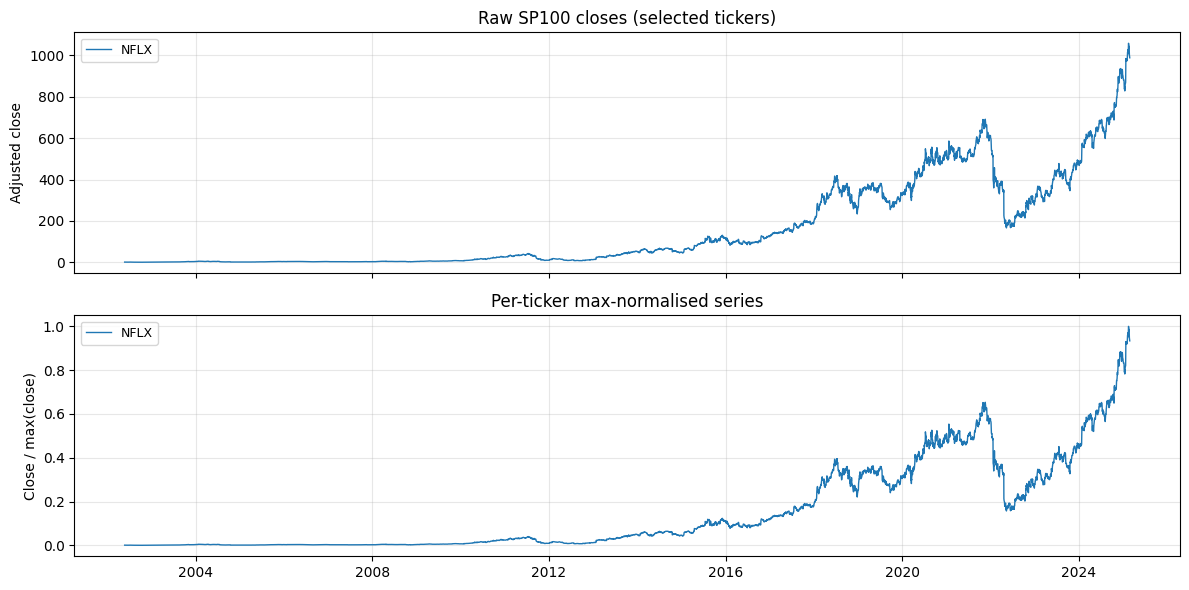

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
sample = TICKERS[0:1]
for sym in sample:
    axes[0].plot(df_raw["Date"], df_raw[sym], label=sym, lw=1)
axes[0].set_ylabel("Adjusted close")
axes[0].set_title("Raw SP100 closes (selected tickers)")
axes[0].legend(ncol=4, fontsize=9)
axes[0].grid(alpha=0.3)

# Normalised view (per-ticker max scaling — same as FeatureGeneration.load_tickers_features)
for sym in sample:
    s = df_raw[sym].dropna()
    axes[1].plot(s.index.map(lambda i: df_raw.loc[i, "Date"]), s / s.max(), label=sym, lw=1)
axes[1].set_ylabel("Close / max(close)")
axes[1].set_title("Per-ticker max-normalised series")
axes[1].legend(ncol=4, fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 1, "raw_sp100_closes")


## 2. Rolling features and RBF encoding

`FeatureGeneration.make_return_variance_features` builds four columns per time step
(after a trailing window of `variance_window` days, default 7 from the parameter file):

| col | meaning | role |
|-----|---------|------|
| 0 | normalised close (value) | unused by the model |
| 1 | simple delta `x[t] − x[t−1]` (no temporal filtering) | unused by the model |
| 2 | **daily return** `x[t] / x[t−1]` | **primary / decode target** |
| 3 | **trailing return variance** (left-sided, direction-agnostic) | **secondary channel** |

The LTSL network predicts column **2** (daily return) at horizon `offs` days ahead.
Inputs are encoded by **two independent 1-D RBF binnings** (return and variance), then combined
via an outer product → `return_nbin × variance_nbin` binary-ish pattern rows written to `features.dat`.

The RBF centre layout follows the `binmode` parameter — `rbf` (linearly spaced centres on a 0.5% winsor range) or `rbf-quantile`
(centres at empirical quantiles with adaptive width). The primary decode-target centres are persisted to a
`features.centers.npy` sidecar so decode/plotting uses the exact centres that were encoded.

'figs/SP100/1ticker/02_rolling_features_NFLX.png'

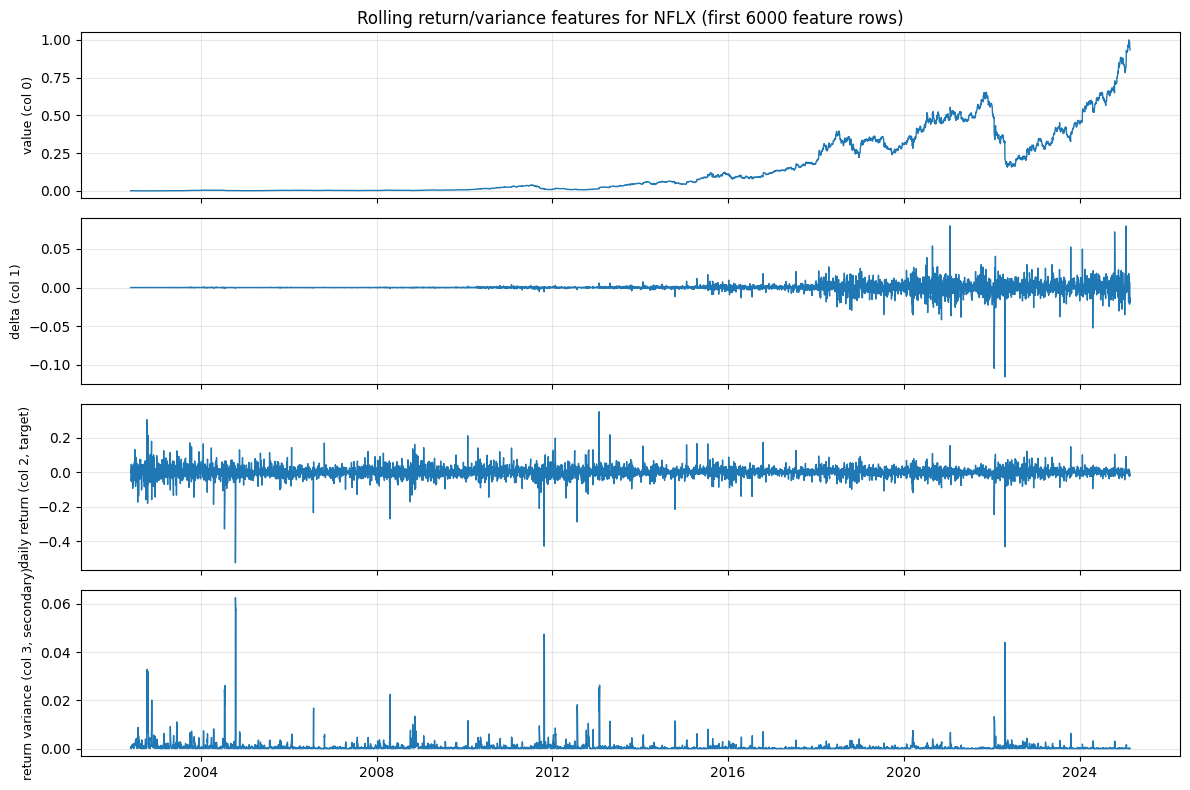

In [4]:
# Use the active feature set (CFG.func -> make_return_variance_features) so the
# per-ticker features here are exactly what Mains.multislice() will encode/run.
per_ticker, csv_lens = FG.load_tickers_features(
    DATA_CSV, ",".join(TICKERS), feature_func=CFG.func, feature_align=W)
demo_sym = TICKERS[0] #'PG'
feats = per_ticker[demo_sym]["feats"]
n_show = 6000
t_axis = df_raw["Date"].iloc[per_ticker[demo_sym]["first_valid_feat_row"]:][:n_show]

fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
labels = ["value (col 0)", "delta (col 1)",
          "daily return (col 2, target)", "return variance (col 3, secondary)"]
for k, ax in enumerate(axs):
    ax.plot(t_axis, feats[:n_show, k], lw=1)
    ax.set_ylabel(labels[k], fontsize=9)
    ax.grid(alpha=0.3)
axs[0].set_title(f"Rolling return/variance features for {demo_sym} (first {n_show} feature rows)")
plt.tight_layout()
save_fig(fig, 2, f"rolling_features_{demo_sym}")


Return decode max |error|: 0.1976


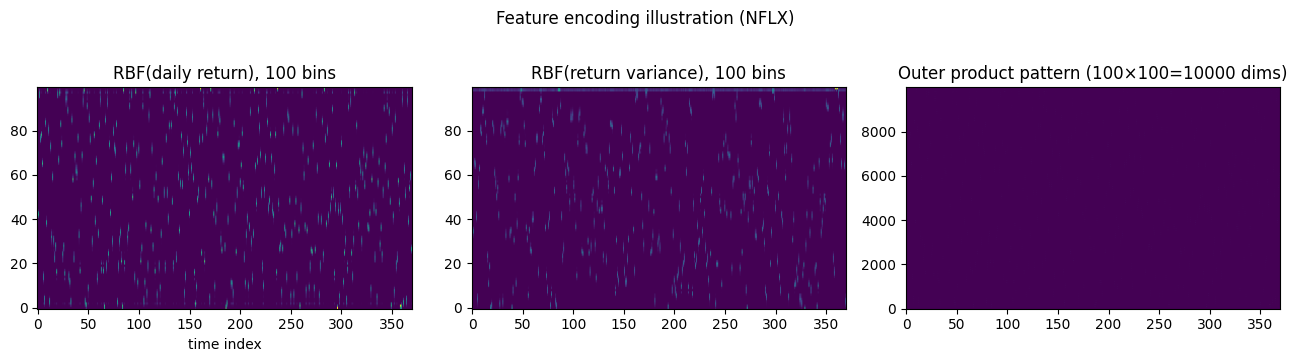

In [5]:
# RBF encoding on a short slice (multislice uses the pooled stream via build_patterns).
# Primary channel = daily return (col 2, decode target); secondary = variance (col 3).
slice_feats = feats[180:550]
enc_return = FG._make_channel_encoder(slice_feats[:, PRIMARY_COL], RETURN_NBIN, CFG.binmode)
enc_var = FG._make_channel_encoder(slice_feats[:, SECONDARY_COL], VARIANCE_NBIN, CFG.binmode)
p_return = enc_return.encode(slice_feats[:, PRIMARY_COL])
p_var = enc_var.encode(slice_feats[:, SECONDARY_COL])
# Primary is the OUTER factor (matches FeatureGeneration.build_patterns / the C++ marginal).
patterns = (p_return[:, :, None] * p_var[:, None, :]).reshape(len(slice_feats), -1)

fig, axs = plt.subplots(1, 3, figsize=(13, 3.5))
axs[0].imshow(p_return[:].T, aspect="auto", origin="lower", cmap="viridis")
axs[0].set_title(f"RBF(daily return), {RETURN_NBIN} bins")
axs[0].set_xlabel("time index")
axs[1].imshow(p_var[:].T, aspect="auto", origin="lower", cmap="viridis")
axs[1].set_title(f"RBF(return variance), {VARIANCE_NBIN} bins")
axs[2].imshow(patterns[:].T, aspect="auto", origin="lower", cmap="viridis")
axs[2].set_title(f"Outer product pattern ({RETURN_NBIN}×{VARIANCE_NBIN}={patterns.shape[1]} dims)")
plt.suptitle(f"Feature encoding illustration ({demo_sym})", y=1.02)
plt.tight_layout()
save_fig(fig, 3, f"rbf_encoding_{demo_sym}")

# Decode round-trip on the return (target) channel
recon = enc_return.decode(p_return)
print(f"Return decode max |error|: {np.max(np.abs(recon - slice_feats[:, PRIMARY_COL])):.4g}")


## 3. Block-wise walk-forward schedule

Instead of holding out entire tickers for testing (which leaks calendar structure), **multislice** cuts
the shared timeline into consecutive blocks. Block `b` spans feature rows
`[calendar_start + b·block_step, …)` with `calendar_start = W−1`.

Within each block, patterns are concatenated in order:

`[train_t0, train_t1, …, val_t0, …, test_t0, …]`

The C++ simulator reads one row per block from `schedule.dat` (`trnpat vanpat tenpat` **totals** for that
block, summed over active tickers). Network state (weights + LTSL memory) **carries across blocks** — this
is continual learning on a single long run.

**Warmup (`warmup_pat`, default 50):** at each ticker-to-ticker cut within a phase (`k > 0`), the first
`warmup_pat` patterns are replayed forward-only (LTSL adapts, weights frozen, outputs not logged). RMSE is
computed only on the remaining suffix of each segment. The first ticker in each phase (`k = 0`) is scored
over the full window. Warmup does **not** add calendar rows or change `block_step`; it replays within each
ticker's `trnpat` / `vanpat` / `tenpat` budget. Require each phase length to be **> `warmup_pat + offs`**; set
`warmup_pat 0` to disable.

Candidate blocks (longest history): 6


'figs/SP100/1ticker/05_block_coverage_train_val_test.png'

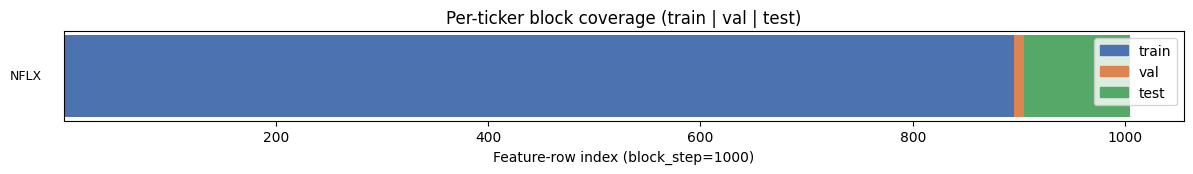

In [6]:
calendar_start = W - 1
max_end = max(d["first_valid_feat_row"] + d["feats"].shape[0] for d in per_ticker.values())
n_blocks = (max_end - calendar_start) // BLOCK_STEP
print(f"Candidate blocks (longest history): {n_blocks}")

# Calendar coverage: train | val | test per block (warmup replays within per_t_len — no extra rows)
phase_colors = {"train": "#4C72B0", "val": "#DD8452", "test": "#55A868"}
fig, ax = plt.subplots(figsize=(12, 0.35 * len(TICKERS[:6]) + 1.5))

for row, sym in enumerate(TICKERS[:6]):
    d = per_ticker[sym]
    fv = d["first_valid_feat_row"]
    n_feat = d["feats"].shape[0]
    for b in range(n_blocks):
        b_start = calendar_start + b * BLOCK_STEP
        sl = b_start - fv
        if sl < 0 or sl + BLOCK_STEP > n_feat:
            continue
        x0 = b
        phase_x = x0
        ax.barh(row, TRNPAT, left=phase_x, color=phase_colors["train"], height=0.8)
        phase_x += TRNPAT
        ax.barh(row, VANPAT, left=phase_x, color=phase_colors["val"], height=0.8)
        phase_x += VANPAT
        ax.barh(row, TENPAT, left=phase_x, color=phase_colors["test"], height=0.8)
    ax.text(-0.02 * BLOCK_STEP, row, sym, ha="right", va="center", fontsize=9)

ax.set_xlabel(f"Feature-row index (block_step={BLOCK_STEP})")
ax.set_yticks([])
ax.set_title("Per-ticker block coverage (train | val | test)")
legend_handles = [Patch(color=c, label=k) for k, c in phase_colors.items()]
ax.legend(handles=legend_handles, loc="upper right")
if WARMUP_PAT > 0:
    ax.text(
        0.99, 0.02,
        f"warmup_pat={WARMUP_PAT}: forward replay at ticker transitions (k>0); not extra calendar rows",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8, style="italic")
plt.tight_layout()
save_fig(fig, 5, "block_coverage_train_val_test")


In [7]:
# Map block indices to calendar dates (using AAPL as reference timeline)
ref = per_ticker[TICKERS[0]]
ref_dates = df_raw["Date"].iloc[ref["first_valid_feat_row"]: ref["first_valid_feat_row"] + ref["feats"].shape[0]]

block_table = []
for b in range(n_blocks):
    sl = calendar_start + b * BLOCK_STEP - ref["first_valid_feat_row"]
    active = [sym for sym in TICKERS
              if 0 <= (calendar_start + b * BLOCK_STEP - per_ticker[sym]["first_valid_feat_row"])
              and (calendar_start + b * BLOCK_STEP - per_ticker[sym]["first_valid_feat_row"] + BLOCK_STEP)
              <= per_ticker[sym]["feats"].shape[0]]
    block_table.append({
        "block": b,
        "train_start": ref_dates.iloc[sl].date() if 0 <= sl < len(ref_dates) else None,
        "test_end": ref_dates.iloc[min(sl + BLOCK_STEP - 1, len(ref_dates)-1)].date() if sl >= 0 else None,
        "n_active_tickers": len(active),
        "schedule_trn": len(active) * TRNPAT,
        "schedule_ten": len(active) * TENPAT,
    })
pd.DataFrame(block_table)

,block,train_start,test_end,n_active_tickers,schedule_trn,schedule_ten
0,0,None,None,0,0,0
1,1,2003-12-30,2007-12-18,1,890,100
2,2,2007-12-19,2011-12-06,1,890,100
3,3,2011-12-07,2015-11-27,1,890,100
4,4,2015-11-30,2019-11-18,1,890,100
5,5,2019-11-19,2023-11-08,1,890,100


## 4. Run Mains.multislice() on the complete ticker list
This invokes ./ltslmain once with the full multi-block schedule. 

In [8]:
#Comment out to skip re-running ltslmain (takes ~15.3sec for one ticker)
result = Mains.multislice(
    PARAMFILE,
    exefile="./ltslmain",
    verbose=True,
    metrics=("rmse", "persistence", "hit", "var"),
    var_level=VAR_LEVEL,
)

Mains.multislice: timeseries_file=sp100_IPO_sorted.csv
  tickers=['NFLX']
  trnpat=890  vanpat=10  tenpat=100  warmup_pat=0  block_step=1000
  calendar_start=2  max_calendar_end=6324  candidate blocks=6
  n_blocks=5  total feature rows=5000  (per-phase totals: trn=4450, van=50, ten=500)


Hj = 1 nactHi = 3 nsilHi = 0 denHi = 3 Mi = 10000 denNi = 30000


paramfile = Parameters_1ticker.par
schedule_file = schedule.dat  (5 blocks; sum trn=4450 van=50 ten=500)
taup = 4.450
eps = 2.2e-04
K_mode = logarithmic
BLOCK 1/5  trnpat=890 vanpat=10 tenpat=100  (simstep=0)
BLOCK 2/5  trnpat=890 vanpat=10 tenpat=100  (simstep=1886)
BLOCK 3/5  trnpat=890 vanpat=10 tenpat=100  (simstep=3772)
BLOCK 4/5  trnpat=890 vanpat=10 tenpat=100  (simstep=5658)
BLOCK 5/5  trnpat=890 vanpat=10 tenpat=100  (simstep=7544)
Total simsteps = 9430, time elapsed = 147.712 sec
  train: mean RMSE = 0.037826  persistence = 0.046131  (5/5 valid entries)
  val  : mean RMSE = 0.031714  persistence = 0.033753  (5/5 valid entries)
  test : mean RMSE = 0.036184  persistence = 0.046843  (5/5 valid entries)


In [9]:
rmse = result["rmse"]          # [n_tickers, 3 phases, n_blocks]
valid = result["valid"]
pers = result["persistence"]
labels = result["tickers"]
n_blocks_run = result["n_blocks"]
phase_names = ["train", "val", "test"]

print(f"RMSE cube shape: {rmse.shape}  (tickers × phases × blocks)")
print(f"Blocks executed: {n_blocks_run}")
print(f"warmup_pat: {result.get('warmup_pat', 0)}")

# Show schedule sidecar written for ltslmain
with open(params["schedule_file"]) as fp:
    sched_lines = fp.read().strip().splitlines()
print(f"\n{params['schedule_file']} ({len(sched_lines)} rows):")
for i, line in enumerate(sched_lines):
    print(f"  block {i}: {line}")

RMSE cube shape: (1, 3, 5)  (tickers × phases × blocks)
Blocks executed: 5
warmup_pat: 0

schedule.dat (5 rows):
  block 0: 890 10 100
  block 1: 890 10 100
  block 2: 890 10 100
  block 3: 890 10 100
  block 4: 890 10 100


## 5. Test error vs. prior learning (block index)

Block index doubles as **how much calendar history the network has already trained on** (cumulative
continual learning). We expect early blocks to behave differently from later ones — especially around
regime changes (e.g. 2008–2009 for cyclical names).

In [10]:
test_rmse = rmse[:, 2, :]   # phase index 2 = test
test_valid = valid[:, 2, :]
prior_train_days = np.arange(n_blocks_run) * BLOCK_STEP  # feature rows seen before each block

# Calendar year at test-phase start (AAPL reference timeline) for x-axis labels on figs 8–9
_ref = per_ticker["NFLX"]
_ref_dates = df_raw["Date"].iloc[
    _ref["first_valid_feat_row"] : _ref["first_valid_feat_row"] + _ref["feats"].shape[0]
]
block_year_labels = []
for b in range(n_blocks_run):
    test_start = calendar_start + b * BLOCK_STEP + TRNPAT + VANPAT - _ref["first_valid_feat_row"]
    if 0 <= test_start < len(_ref_dates):
        block_year_labels.append(str(_ref_dates.iloc[test_start].year))
    else:
        block_year_labels.append(str(b))

stockperformance = np.nanmean(test_rmse, axis=1)
# Next Find indices of 5 best and worst performers
bottom5_idx = np.argsort(stockperformance)[-5:][::-1]
top5_idx = np.argsort(stockperformance)[:5]
bottom5_labels = [labels[i] for i in bottom5_idx]
top5_labels = [labels[i] for i in top5_idx]

'figs/SP100/1ticker/09_test_rmse_heatmap_tickers_blocks.png'

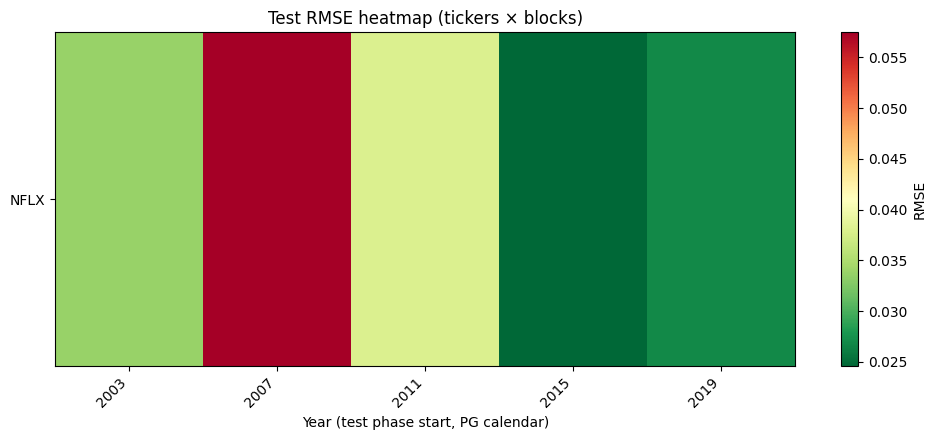

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(test_rmse, aspect="auto", cmap="RdYlGn_r", origin="lower")  # green to red (reversed)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xticks(range(n_blocks_run))
ax.set_xticklabels(block_year_labels, rotation=45, ha="right")
ax.set_xlabel("Year (test phase start, PG calendar)")
ax.set_title("Test RMSE heatmap (tickers × blocks)")
plt.colorbar(im, ax=ax, label="RMSE")
plt.tight_layout()
save_fig(fig, 9, "test_rmse_heatmap_tickers_blocks")

## 6. Cross-stock comparison on the ticker sample

Summarise **mean test RMSE over all blocks** and check dispersion. Consumer staples (KO, PG) often show
lower error than volatile tech / industrial names; crisis-era blocks inflate error for cyclicals.

,ticker,mean_test_rmse,std_test_rmse,max_test_rmse,mean_persistence,beats_persistence
0,NFLX,0.0362,0.0117,0.0575,0.0468,1.0


'figs/SP100/1ticker/10_cross_sectional_mean_test_rmse.png'

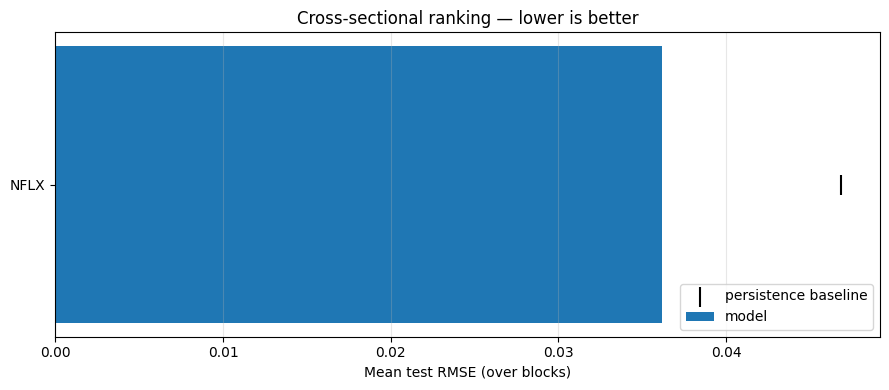

In [12]:
summary_rows = []
for i, sym in enumerate(labels):
    m = test_valid[i]
    summary_rows.append({
        "ticker": sym,
        "mean_test_rmse": float(np.nanmean(test_rmse[i, m])),
        "std_test_rmse": float(np.nanstd(test_rmse[i, m])),
        "max_test_rmse": float(np.nanmax(test_rmse[i, m])),
        "mean_persistence": float(np.nanmean(pers[i, 2, m])),
        "beats_persistence": float(np.nanmean(test_rmse[i, m] < pers[i, 2, m])),
    })
summary = pd.DataFrame(summary_rows).sort_values("mean_test_rmse")
display(summary.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.tab10(np.linspace(0, 1, len(summary)))
ax.barh(summary["ticker"], summary["mean_test_rmse"], color=colors, label="model")
ax.scatter(summary["mean_persistence"], summary.index, marker="|", s=200, c="k", zorder=3, label="persistence baseline")
ax.set_xlabel("Mean test RMSE (over blocks)")
ax.set_title("Cross-sectional ranking — lower is better")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
save_fig(fig, 10, "cross_sectional_mean_test_rmse")


## 6b. Test prediction and uncertainty (BA)

After a multislice run, model outputs live in the concatenated ``netw1_outpop_*_dist.bin`` streams — one logged row per scored step, in block / phase / ticker order (warmup replay steps are omitted). ``Display.stitch_multislice_ticker`` inverts that layout for a single symbol; ``Display.plot_multislice_prediction(..., phases="test")`` returns ``(fig, ax, rmses)`` so the plot can be adjusted in the notebook before saving; it draws only the **unseen/test** decoded **daily return** (the primary channel) with central credible bands (same convention as ``plot_general_prediction``).


NFLX: 495 test steps across 5 blocks
Selected step 2941: block 2  truth=-0.01538  pred=-0.0007408
Click the price or return panel to inspect the pmf at that timestep.


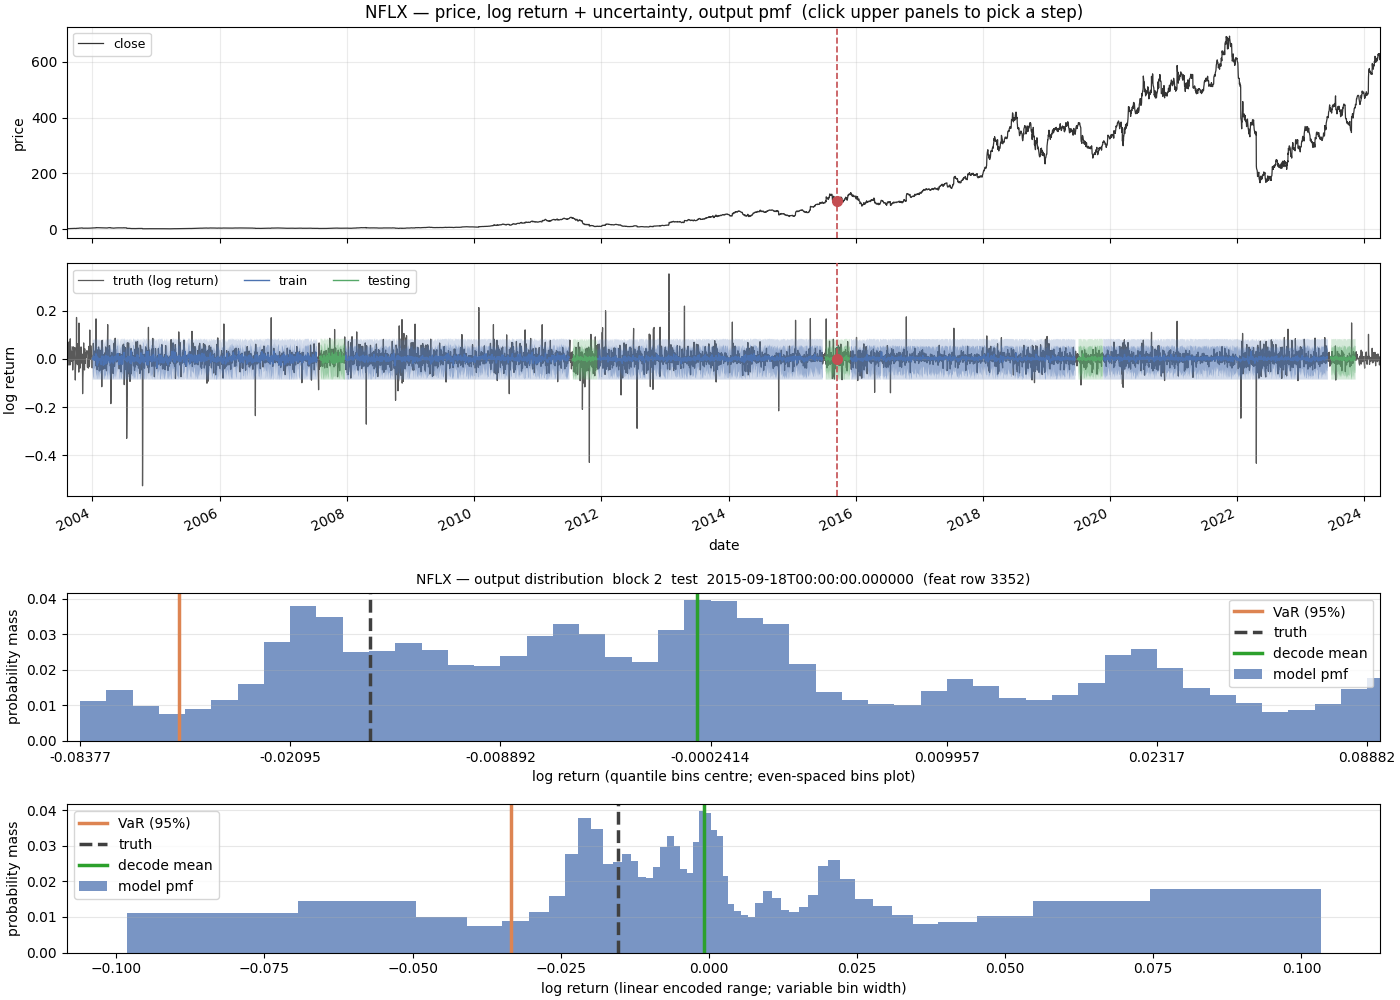

In [17]:
# Interactive price / log-return / output-pmf explorer 
# Click the upper panels to update the pmf
for m in (Utils, FG, Mains, Display):
    importlib.reload(m)

_ip = get_ipython()
try:
    import ipympl  # noqa: F401
    _ip.run_line_magic("matplotlib", "widget")
except ImportError:
    _ip.run_line_magic("matplotlib", "inline")

sym = "NFLX"
series_sym = Display.stitch_multislice_ticker(PARAMFILE, sym)
sym_dates = Display.ticker_feat_dates(df_raw["Date"], series_sym)
test_pts = int((series_sym["phase"] == 2).sum())
print(f"{sym}: {test_pts} test steps across "
      f"{series_sym['block'].max() + 1} blocks")

sym_close = df_raw.set_index("Date")[sym].reindex(sym_dates).to_numpy()
test_steps = np.where(series_sym["phase"] == 2)[0]
INITIAL_STEP = int(test_steps[len(test_steps) // 2])   # change to jump on re-run

plt.close("all")
explorer = Display.plot_multislice_explorer(
    PARAMFILE,
    sym,
    result=result,
    series=series_sym,
    dates=sym_dates.values,
    close_prices=sym_close,
    step=INITIAL_STEP,
    phases=["test", "train"],
    confidence_levels=(0.9, 0.99),
    interactive=True,
)
print(f"Selected step {explorer['step']}: block {explorer['info']['block']}  "
      f"truth={explorer['info']['truth']:.4g}  pred={explorer['info']['pred']:.4g}  "
      f"VaR={explorer['info']['var']:.4g}")
if explorer["cid"] is not None:
    print("Click the price or return panel to inspect the pmf at that timestep.")
else:
    print("Using step slider (install ipympl for click-to-update: %pip install ipympl).")
save_fig(explorer["fig"], 16, f"multislice_explorer_{sym}_step{explorer['step']}")
Display.display_multislice_explorer(explorer)